In [46]:
import pandas as pd
# DEFINE LA RUTA
ruta = r"C:\Users\brv_1\Documents\Programacion\PORTAFOLIOS\DASHBOARDS2\CALIDAD_AGUA\database\clean\Base_Calidad_Agua_Profesional_clean.xlsx"
df = pd.read_excel(ruta)
df = df.drop(['Latitud', 'Longitud'], axis=1)

df.describe()

,Fecha,pH,OD,Turbidez,Conductividad,Nitratos,DBO5,Fosfatos,Arsenico,Precipitacion_mm,Temperatura_Aire_C
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2023-07-05 04:53:28.320000,7.490423,6.158706,30.647121,851.338263,7.608687,4.155828,0.440605,0.005609,18.919620,14.979920
min,2021-01-02 00:00:00,5.800000,1.010000,0.500000,256.300000,0.130000,0.500000,0.010000,0.000500,0.000000,3.600000
25%,2022-04-12 00:00:00,7.240000,5.327500,9.400000,522.475000,3.030000,2.760000,0.283000,0.004100,0.200000,13.000000
50%,2023-06-29 00:00:00,7.485000,6.585000,13.700000,723.250000,5.320000,4.155828,0.440605,0.005609,10.100000,14.900000
75%,2024-10-05 00:00:00,7.700000,7.600000,20.225000,970.900000,7.970000,5.540000,0.597000,0.007100,38.800000,17.000000
max,2025-12-31 00:00:00,9.300000,9.570000,179.800000,2199.200000,29.990000,8.180000,0.829000,0.010300,74.800000,26.100000
std,NaN,0.789738,1.946602,42.146782,461.263181,7.047377,1.674339,0.184936,0.001907,20.180553,2.973601


In [47]:
df.corr(numeric_only=True)

,pH,OD,Turbidez,Conductividad,Nitratos,DBO5,Fosfatos,Arsenico,Precipitacion_mm,Temperatura_Aire_C
pH,1.000000,0.060812,0.008427,-0.038136,-0.016624,-0.170228,-0.167181,-0.159798,0.013928,0.006707
OD,0.060812,1.000000,-0.779649,-0.903055,-0.873471,-0.663684,-0.668887,-0.630378,0.002098,-0.019081
Turbidez,0.008427,-0.779649,1.000000,0.807408,0.834828,0.377347,0.373992,0.356893,0.047971,0.005507
Conductividad,-0.038136,-0.903055,0.807408,1.000000,0.891441,0.631622,0.633961,0.595974,-0.046903,0.021270
Nitratos,-0.016624,-0.873471,0.834828,0.891441,1.000000,0.547718,0.547406,0.517256,-0.009789,0.015283
DBO5,-0.170228,-0.663684,0.377347,0.631622,0.547718,1.000000,0.919381,0.859249,-0.004967,0.012285
Fosfatos,-0.167181,-0.668887,0.373992,0.633961,0.547406,0.919381,1.000000,0.874337,-0.000846,0.015816
Arsenico,-0.159798,-0.630378,0.356893,0.595974,0.517256,0.859249,0.874337,1.000000,-0.000167,0.012911
Precipitacion_mm,0.013928,0.002098,0.047971,-0.046903,-0.009789,-0.004967,-0.000846,-0.000167,1.000000,-0.015319
Temperatura_Aire_C,0.006707,-0.019081,0.005507,0.021270,0.015283,0.012285,0.015816,0.012911,-0.015319,1.000000


In [48]:
df.groupby('Fecha')['OD'].mean()

Fecha
2021-01-02    7.322000
2021-01-03    5.820000
2021-01-04    4.186667
2021-01-05    5.475000
2021-01-06    5.948000
                ...   
2025-12-27    5.058000
2025-12-28    5.100000
2025-12-29    8.395000
2025-12-30    6.045000
2025-12-31    6.317500
Name: OD, Length: 1711, dtype: float64

In [49]:
df.groupby('Estacion')['Turbidez'].mean()

Estacion
CH-01     9.224261
CH-02    13.289965
CH-03    18.865094
CH-04    23.019157
CH-05    30.685145
CH-06    40.286929
CH-07    52.464235
CH-08    57.502561
Name: Turbidez, dtype: float64

GRAFICOS

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

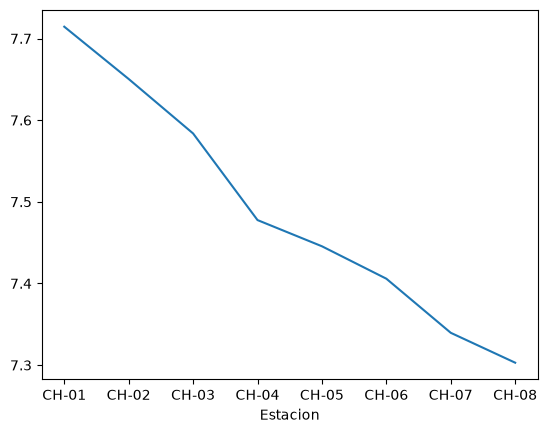

In [50]:
df.groupby('Estacion')['pH'].mean().plot()
#plt.show()
plt.savefig(r"C:\Users\brv_1\Documents\Programacion\PORTAFOLIOS\DASHBOARDS2\CALIDAD_AGUA\imagenes\tendenciapH.png")

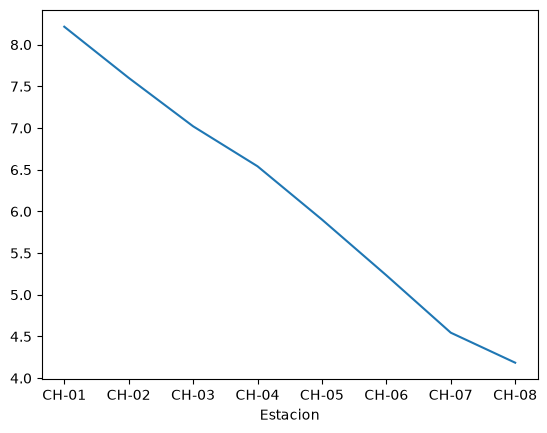

In [52]:
df.groupby("Estacion")["OD"].mean().plot()
plt.savefig(r"C:\Users\brv_1\Documents\Programacion\PORTAFOLIOS\DASHBOARDS2\CALIDAD_AGUA\imagenes\tendencia_OD.png")

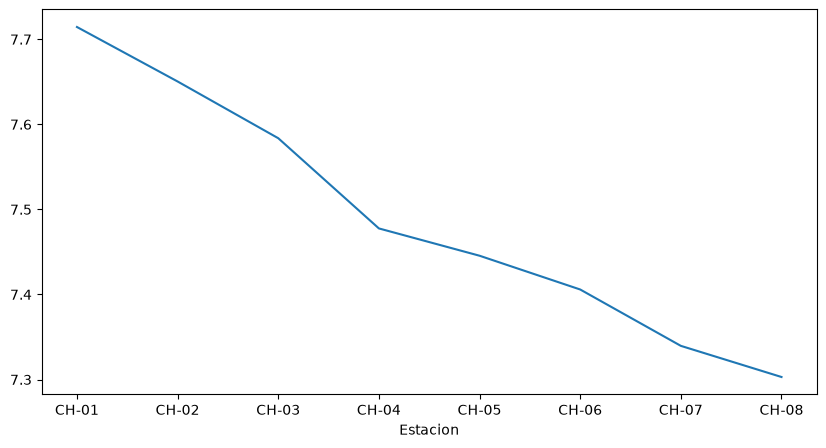

In [18]:
data = df.groupby('Estacion')['pH'].mean().plot(figsize=(10,5), layout='constrained')

<Axes: xlabel='Fecha'>

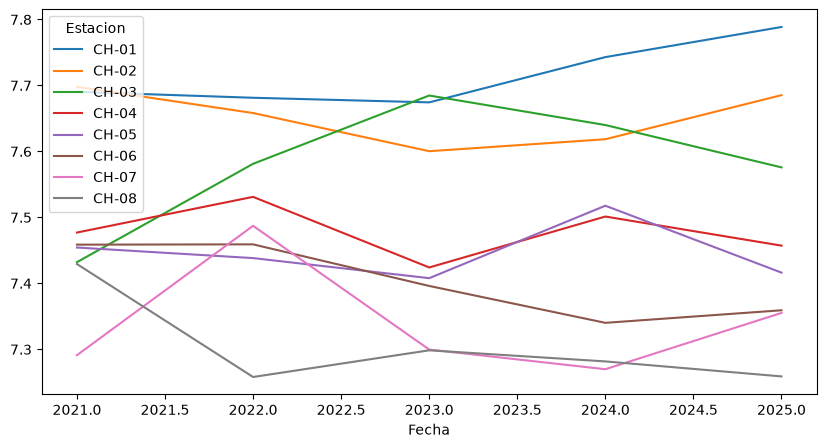

In [37]:
df.groupby([df['Fecha'].dt.year, 'Estacion'])['pH'].mean().unstack().plot(figsize=(10,5), layout='constrained')

c:\Users\brv_1\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\plotting\_matplotlib\core.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  return ax.errorbar(x, y, **kwds)


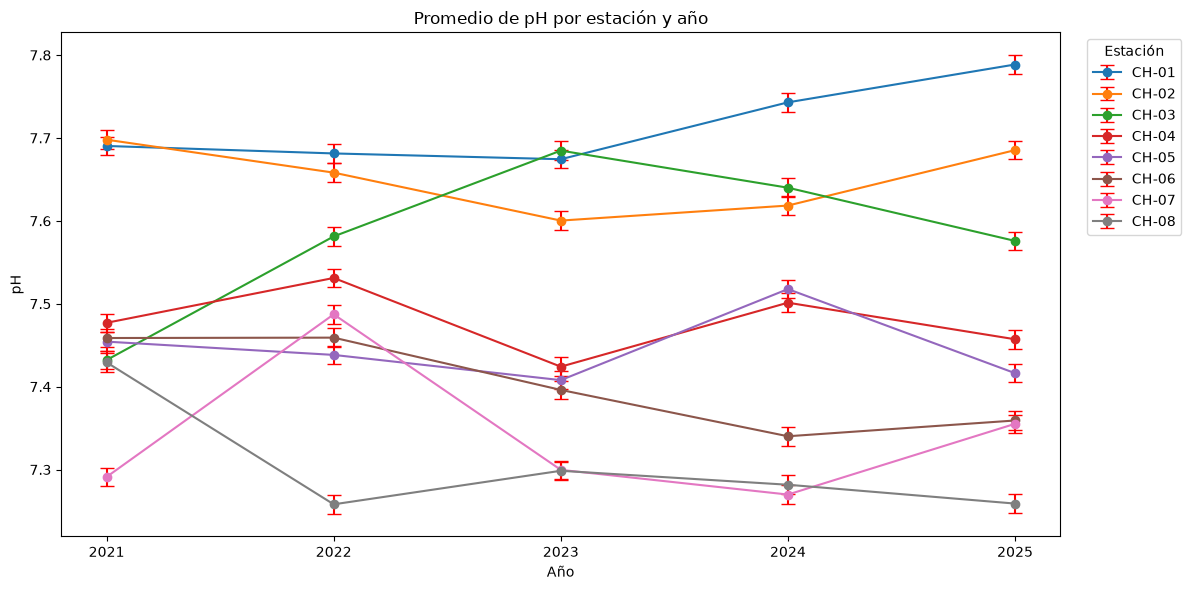

In [36]:
#from matplotlib.ticker import MaxNLocator
df['Fecha'] = pd.to_datetime(df['Fecha'])
error_estandar = df['pH'].sem()
ax = (df.groupby([df['Fecha'].dt.year,'Estacion'])['pH']
        .mean()
        .unstack()
        .plot(figsize=(12,6), yerr = error_estandar, fmt='-o', capsize=5, ecolor='red', marker='o'))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('Promedio de pH por estación y año')
ax.set_xlabel('Año')
ax.set_ylabel('pH')
ax.grid(False)
plt.legend(title='Estación', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\brv_1\Documents\Programacion\PORTAFOLIOS\DASHBOARDS2\CALIDAD_AGUA\imagenes\plot_pH.png")
plt.show()

c:\Users\brv_1\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\plotting\_matplotlib\core.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  return ax.errorbar(x, y, **kwds)


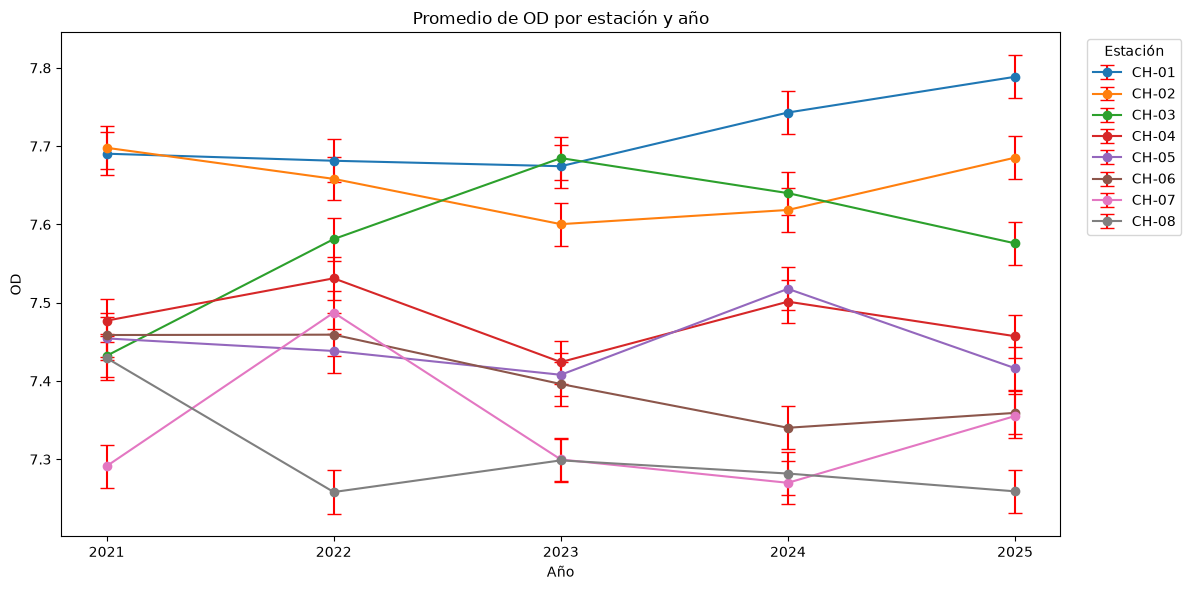

In [42]:
df['Fecha'] = pd.to_datetime(df['Fecha'])
error_estandar = df['OD'].sem()
ax = (df.groupby([df['Fecha'].dt.year,'Estacion'])['pH']
        .mean()
        .unstack()
        .plot(figsize=(12,6), yerr = error_estandar, fmt='-o', capsize=5, ecolor='red', marker='o'))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('Promedio de OD por estación y año')
ax.set_xlabel('Año')
ax.set_ylabel('OD')
ax.grid(False)
plt.legend(title='Estación', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\brv_1\Documents\Programacion\PORTAFOLIOS\DASHBOARDS2\CALIDAD_AGUA\imagenes\plot_OD.png")
plt.show()

Text(0.5, 1.0, 'Promedio anual de pH por estación')

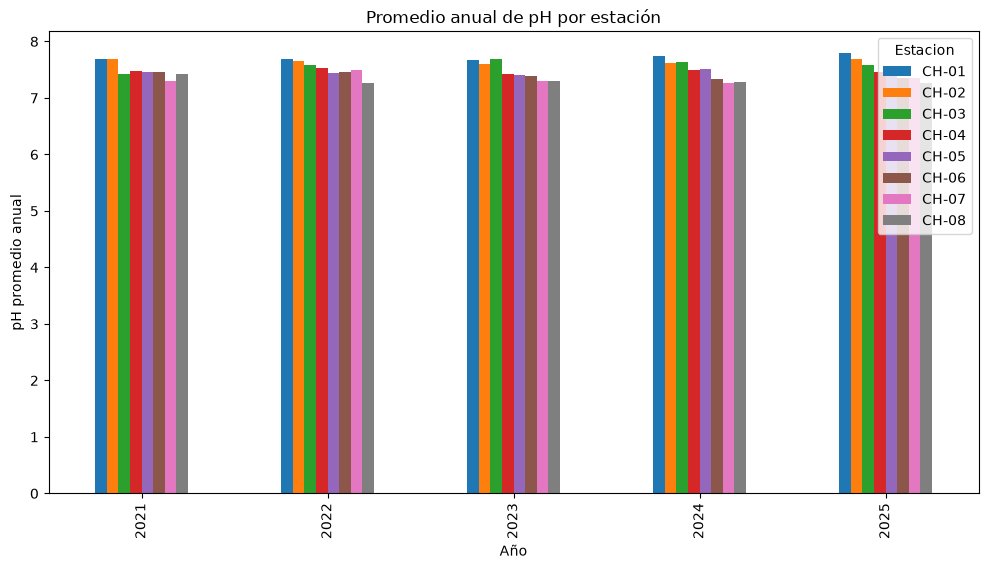

In [26]:
ax = (df.groupby([df['Fecha'].dt.year, 'Estacion'])['pH']
        .mean()
        .unstack()
        .plot(kind='bar', figsize=(12,6)))

ax.set_xlabel('Año')
ax.set_ylabel('pH promedio anual')
ax.set_title('Promedio anual de pH por estación')

<Axes: xlabel='Fecha'>

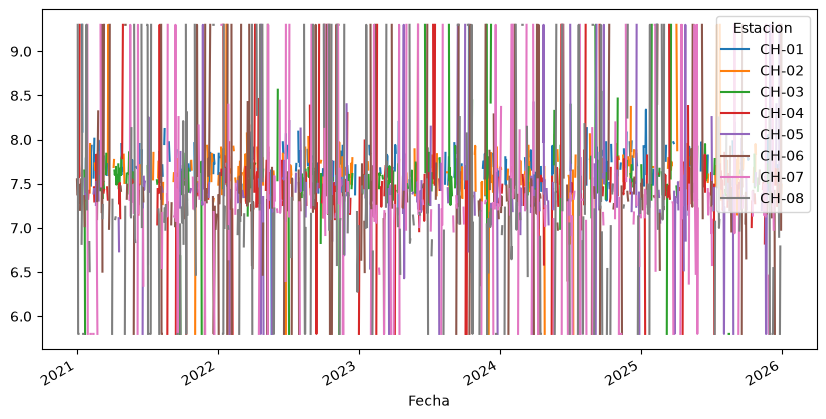

In [15]:
tabla = df.pivot_table(
    index='Fecha',
    columns='Estacion',
    values='pH',
    aggfunc='mean'
)

tabla.plot(figsize=(10,5))

Text(0, 0.5, 'pH')

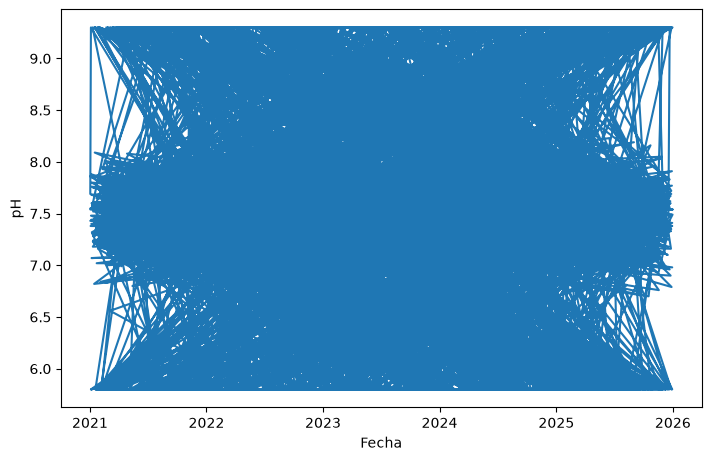

In [ ]:
# NO CONSIDERAR
fig, ax = plt.subplots(figsize=(7, 4.5), layout = 'constrained')
ax.plot('Fecha', 'pH', data=df)
ax.set_xlabel('Fecha')
ax.set_ylabel('pH')

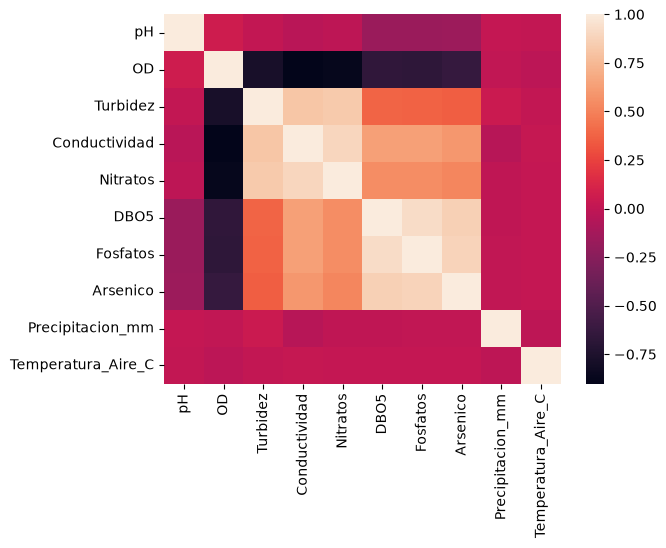

In [53]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True))
plt.savefig(r"C:\Users\brv_1\Documents\Programacion\PORTAFOLIOS\DASHBOARDS2\CALIDAD_AGUA\imagenes\plot_Heat.png")